In [1]:
import os
from typing import TypedDict, Annotated, Literal
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
search_tool = TavilySearch(max_results= 3 )

In [4]:
tools = [search_tool]

In [5]:
# writer llm

writer_llm = ChatGroq(model="openai/gpt-oss-120b",temperature=0.7)
writer_llm_with_tools = writer_llm.bind_tools(tools)

In [6]:
# reviewer _ llm
reviewer_llm = ChatGroq(model="openai/gpt-oss-20b",temperature=0.1)

In [7]:
class State(TypedDict):
    topic : str
    messages: Annotated[list, add_messages]
    draft : str
    review_feedback : str
    is_approved : bool
    attempt : int


In [8]:
# nodes

WRITER_SYSTEM_PROMPT = (
"You are an expert LinkedIn content writer. Your job is to write "
"engaging, professional LinkedIn posts about the given topic. "
"If the topic requires up-to-date information, statistics, or "
"current trends, use the web search tool to gather fresh context "
"before writing. If you have already received feedback on a "
"previous draft, carefully address every point in the new draft. "
"Rules for good LinkedIn posts: strong hook in the first line, "
"1 clear takeaway, easy to skim (short paragraphs), around "
"150-200 words, ends with a question or call-to-action to invite "
"engagement. Do not use hashtags."
)

In [9]:
def writer_node(state : State) -> dict:
    """Writes (or rewrites) the LinkdIn post. Can call Tavily to search first."""
    existing_messages = state.get("messages", [])

    # If we're coming back from the tool node, the last message is the
    # search result. Continue the SAME conversation so the LLM can see
    # what it searched for and now write the actual post, instead of
    # starting a brand-new prompt that throws the search result away.
    if existing_messages and getattr(existing_messages[-1], "type", None) == "tool":
        response = writer_llm_with_tools.invoke(existing_messages)
        return {"messages": [response]}

    attempt = state.get("attempt",0) + 1
    topic = state['topic']
    previous_feedback = state['review_feedback']

    if attempt == 1:
        user_message = (
            f"Write a LinkedIn post on this topic {topic}"
            f"if you need the current info just search the web first"
        )
    else:
        user_message = (
            f"your previous draft on '{topic}' was rejected"
            f"Here is the reviewer's feedback \n\n {previous_feedback}\n\n"
            f"Write a new, improved draft that fixes every issue mentioned"
            f"do not repeat the same mistake"
        )
    messages = [("system",WRITER_SYSTEM_PROMPT),("human",user_message)]
    response = writer_llm_with_tools.invoke(messages)


    return {
        "messages" : [("human", user_message), response],
        "attempt" : attempt
    }




In [10]:
tool_node = ToolNode(tools)

In [11]:
def extract_draft_node(state:State) -> dict:
    """After the writer finishes tool calls, pulls the final text out as the draft."""
    last_message = state['messages'][-1]
    draft = last_message.content
    print(f"\n\n genrated post \n {draft} \n")
    return {"draft":draft}

In [12]:
REVIEWER_SYSTEM_PROMPT = (
    "You are a strict LinkedIn content reviewer. You judge whether a "
    "post is publish-ready. Evaluate against these criteria:\n"
    "1. Strong hook in the first line\n"
    "2. One clear, valuable takeaway\n"
    "3. Easy to skim - uses short paragraphs\n"
    "4. Roughly 150-200 words\n"
    "5. Ends with an engaging question or CTA\n"
    "6. Professional but human tone (not corporate-robotic)\n"
    "7. No hashtags\n\n"
    "Respond in exactly this format:\n"
    "VERDICT: APPROVED or REJECTED\n"
    "FEEDBACK: <one short paragraph explaining why>\n\n"
    "Be strict but fair. Approve only if the post genuinely meets all "
    "criteria. Reject if even one criterion is clearly missing."
)

REVIEWER_SYSTEM_PROMPT

'You are a strict LinkedIn content reviewer. You judge whether a post is publish-ready. Evaluate against these criteria:\n1. Strong hook in the first line\n2. One clear, valuable takeaway\n3. Easy to skim - uses short paragraphs\n4. Roughly 150-200 words\n5. Ends with an engaging question or CTA\n6. Professional but human tone (not corporate-robotic)\n7. No hashtags\n\nRespond in exactly this format:\nVERDICT: APPROVED or REJECTED\nFEEDBACK: <one short paragraph explaining why>\n\nBe strict but fair. Approve only if the post genuinely meets all criteria. Reject if even one criterion is clearly missing.'

In [13]:
def reviewer_node(state:State) -> dict:
    """Reviews the draft and decides: approve or reject with feedback."""
    draft = state['draft']

    prompt = (
        f"review this LinkedIn post draft : \n"
        f"{draft}\n"
        f"give your reviews"
    )
    response = reviewer_llm.invoke(
        [("system",REVIEWER_SYSTEM_PROMPT),("human",prompt)]
    )
    review_text = response.content.strip()
    is_approved = "APPROVED" in review_text.upper().split("FEEDBACK")[0]

    if "FEEDBACK:" in review_text:
        feedback = review_text.split("FEEDBACK:", 1)[1].strip()
    else:
        feedback = review_text
    verdict = "APPROVED" if is_approved else "REJECTED"
    print(f"[Veedict: {verdict}]")
    print(f"[Feedback:] {feedback}")

    return {
        "review_feedback" : feedback,

        "is_approved" : is_approved
    }

In [14]:
# Router Function

def should_use_tool(stste:State):
    last_message = stste['messages'][-1]

    if getattr(last_message,'tool_calls',None):
        return "tools"
    return "extract_draft"


In [15]:
def should_stop_looping(state:State):
    if state['is_approved']:
        print("post has been approved\n")
        return END
    if state['attempt'] >= 3:
        print("reached max attempts")
        return END
    return "writer"


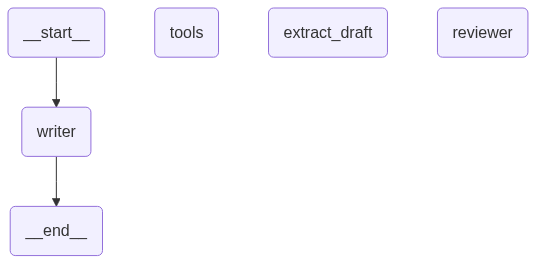

In [16]:
graph = StateGraph(State)

graph.add_node("writer",writer_node)
graph.add_node("tools",tool_node)
graph.add_node("extract_draft",extract_draft_node)
graph.add_node("reviewer",reviewer_node)

graph.add_edge(START,"writer")

graph.add_conditional_edges(
    "writer",should_use_tool
)

graph.add_edge("tools","writer")
graph.add_edge("extract_draft","reviewer")


graph.add_conditional_edges(
    "reviewer",should_stop_looping   
)

app = graph.compile()
app

In [17]:
print("=" * 55)
print("Welcome to the LinkedIn Post Generator")
print("=" * 55)
print("\nThis tool will draft a LinkedIn post for you, review it")
print("itself, and iterate until it's publish-ready.")

print("=" * 55)

topic = input("\nWhat topic do you want a LinkedIn post about?\n> ").strip()

if not topic:
    print("\nNo topic given. Exiting.")
else:
    print("\nStarting generation...\n")

    initial_state = {
        "topic": topic,
        "messages": [],
        "draft": "",
        "review_feedback": "",
        "is_approved": False,
        "attempt": 0,
    }

    final_state = app.invoke(initial_state)

    print("\n" + "=" * 55)
    print("FINAL LINKEDIN POST")
    print("=" * 55)
    print(final_state["draft"])
    print("=" * 55)
    print(f"Total attempts: {final_state['attempt']}")
    print(f"Approved: {final_state['is_approved']}")

Welcome to the LinkedIn Post Generator

This tool will draft a LinkedIn post for you, review it
itself, and iterate until it's publish-ready.

Starting generation...



 genrated post 
 **🚀 AI is Redefining the Junior‑Developer Journey – What the Data Shows (2024‑2025)**  

🔍 **Why this matters:**  
Junior engineers are the engine of every tech org, but they also face the steepest learning curves. The rise of AI‑assisted coding tools (GitHub Copilot, Cursor, CodeWhisperer, etc.) is turning that curve into a gentle slope—if you know how to ride it.

---

### 📊 The hard numbers (2024‑2025)

| Metric | Latest Findings |
|--------|-----------------|
| **Adoption** | 97 % of developers now use at least one AI coding assistant (up from 92 % in 2023). |
| **Code generated by AI** | AI writes **45 %** of a typical developer’s code; in Java projects the share climbs to **61 %**. |
| **Productivity boost** | Controlled experiments show **55 %** faster task completion and **30 %** less debugging 